# Weather Prediction NowCasting Model Scaffold

This notebook scaffolds a machine learning model to predict weather conditions based on data from InfluxDB.

### Objectives:
1.  **Data Ingestion**: Fetch data from locally hosted InfluxDB (Bucket: `OpenMeteo`).
2.  **Feature Engineering**: Create lags, rolling statistics, and temporal features.
3.  **Feature Selection**: Determine the most useful features.
4.  **Multi-target Prediction**: Predict `temperature`, `precipitation_probability`, and `wind_speed`.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from influxdb_client import InfluxDBClient
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
from weather_utils import fetch_influx_data, engineer_features

# Load environment variables from .env file
load_dotenv()

# Load data
df_raw = fetch_influx_data()
print(f"Data loaded. Shape: {df_raw.shape}")
print(f"Locations: {df_raw['location'].unique()}")
df_raw.head()

Data loaded. Shape: (26229, 13)
Locations: <StringArray>
['dubois', 'lander', 'pinedale']
Length: 3, dtype: str


,time,location,cloud_cover,cloud_cover_high,cloud_cover_low,cloud_cover_mid,precipitation,rain,relative_humidity,snow_depth,snowfall,temperature,wind_speed
0,2025-02-25 00:00:00+00:00,dubois,95.0,60.0,81.0,36.0,0.0,0.0,70.972717,0.82,0.0,4.2535,24.201132
1,2025-02-25 01:00:00+00:00,dubois,80.0,30.0,3.0,73.0,0.0,0.0,68.531563,0.82,0.0,3.5535,25.098223
2,2025-02-25 02:00:00+00:00,dubois,62.0,61.0,0.0,3.0,0.0,0.0,69.739517,0.82,0.0,2.0035,20.265795
3,2025-02-25 03:00:00+00:00,dubois,28.0,26.0,2.0,1.0,0.0,0.0,73.094170,0.82,0.0,0.1035,15.042659
4,2025-02-25 04:00:00+00:00,dubois,84.0,83.0,1.0,5.0,0.0,0.0,77.022247,0.81,0.0,-1.6465,11.952054


### Feature Engineering

We will create several types of features:
1.  **Temporal Features**: Extract hour, day, month from timestamp.
2.  **Lagged Features**: Use past values (e.g., 1h, 3h, 6h ago) to predict future ones.
3.  **Rolling Statistics**: Moving averages and standard deviations to capture trends.


In [2]:
df_engineered = engineer_features(df_raw)
print(f"Feature Engineering complete. Shape: {df_engineered.shape}")

Feature Engineering complete. Shape: (26157, 50)


### Feature Selection & Correlation
Let's look at how features correlate with our targets: `temperature`, `precipitation_probability`, and `wind_speed`.


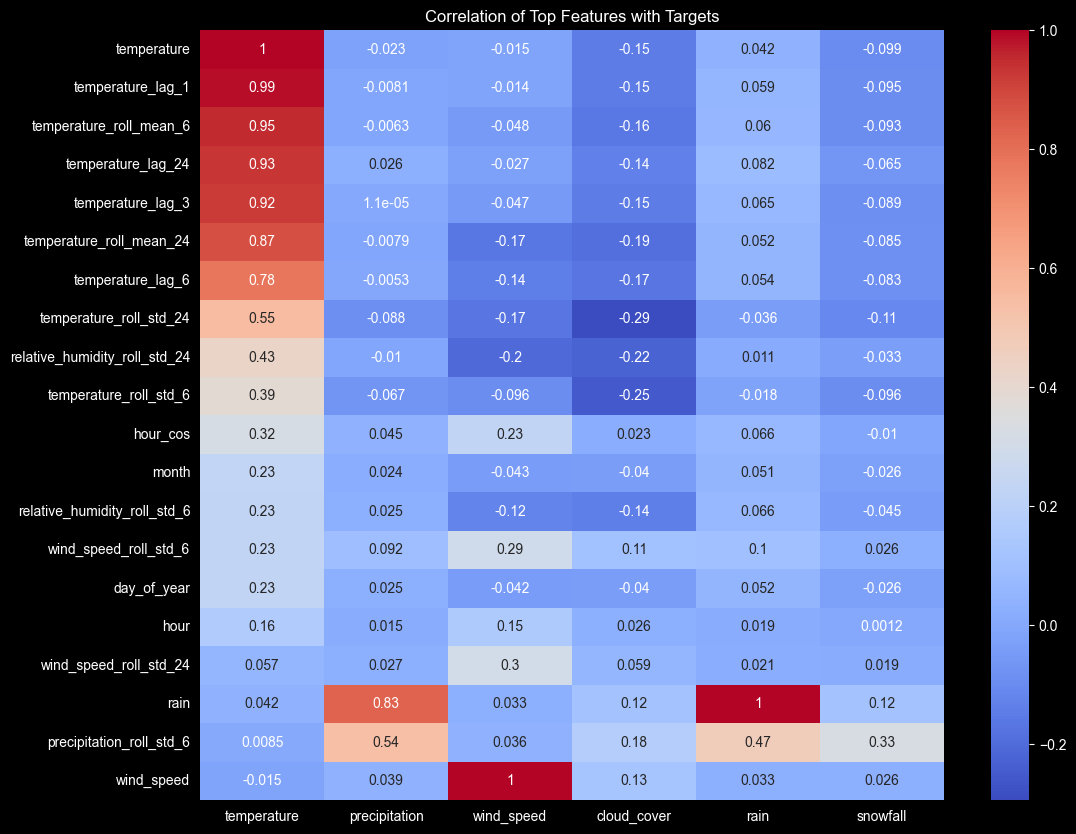

In [5]:
# Define targets
targets = ['temperature', 'precipitation', 'wind_speed', 'cloud_cover', 'rain', 'snowfall']

# Note: If precipitation_probability is missing in data, we can create a dummy or skip it for this scaffold
for target in targets:
    if target not in df_engineered.columns:
        print(f"Warning: {target} missing in data. Creating a placeholder (using 'precipitation' as proxy if available).")
        if target == 'precipitation_probability' and 'precipitation' in df_engineered.columns:
            df_engineered[target] = (df_engineered['precipitation'] > 0).astype(float)
        else:
            df_engineered[target] = 0.0

corr_matrix = df_engineered.drop(columns=['time', 'location']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[targets].sort_values(by=targets, ascending=False).head(20), annot=True, cmap='coolwarm')
plt.title("Correlation of Top Features with Targets")
plt.show()


### Model Training
We will use a `MultiOutputRegressor` wrapping a `RandomForestRegressor` to predict all three targets simultaneously.


In [6]:
# 1. Define Features and Targets
drop_cols = ['time', 'location'] + targets
X = df_engineered.drop(columns=drop_cols)
y = df_engineered[targets]

# 2. Encode categorical 'location' if we want to use it as a feature
X = pd.concat([X, pd.get_dummies(df_engineered['location'], prefix='loc')], axis=1)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Model Definition
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))

# 5. Fit Model
print("Training model...")
model.fit(X_train, y_train)
print("Training complete.")


Training model...
Training complete.


### Evaluation
Evaluate the model performance using RMSE and R² Score for each target.


Target: temperature               | RMSE: 0.6508 | R2: 0.9956
Target: precipitation             | RMSE: 0.1762 | R2: 0.6485
Target: wind_speed                | RMSE: 2.4274 | R2: 0.8871
Target: cloud_cover               | RMSE: 1.5615 | R2: 0.9986
Target: rain                      | RMSE: 0.1451 | R2: 0.6205
Target: snowfall                  | RMSE: 0.0769 | R2: 0.4232


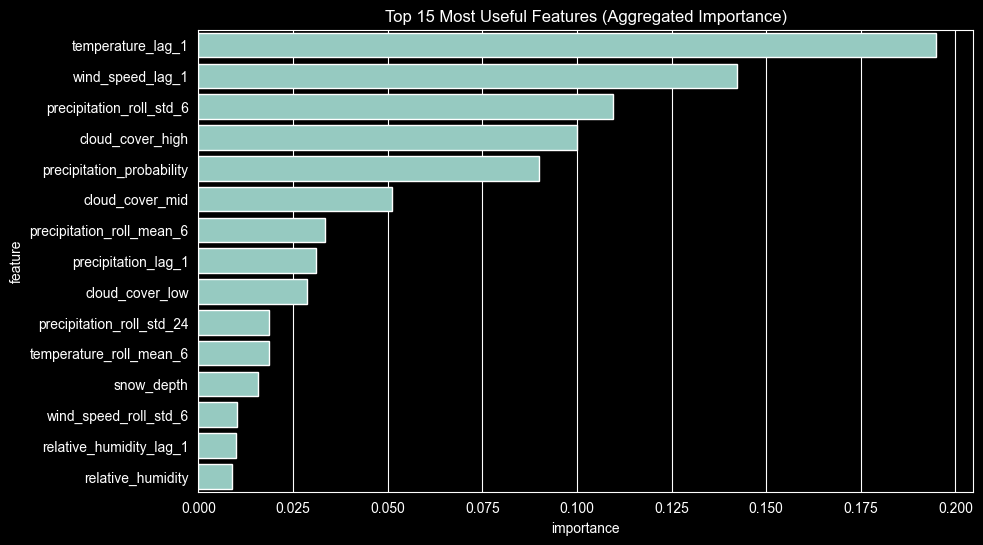

In [7]:
y_pred = model.predict(X_test)

for i, target in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"Target: {target:25} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

# Feature Importance for the Multi-Output Model (Aggregated)
importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)
feature_importance_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15))
plt.title("Top 15 Most Useful Features (Aggregated Importance)")
plt.show()


### Future Temperature Predictions Visualization
Visualize the "Nowcasted" temperature predictions against the actual values for the test period.


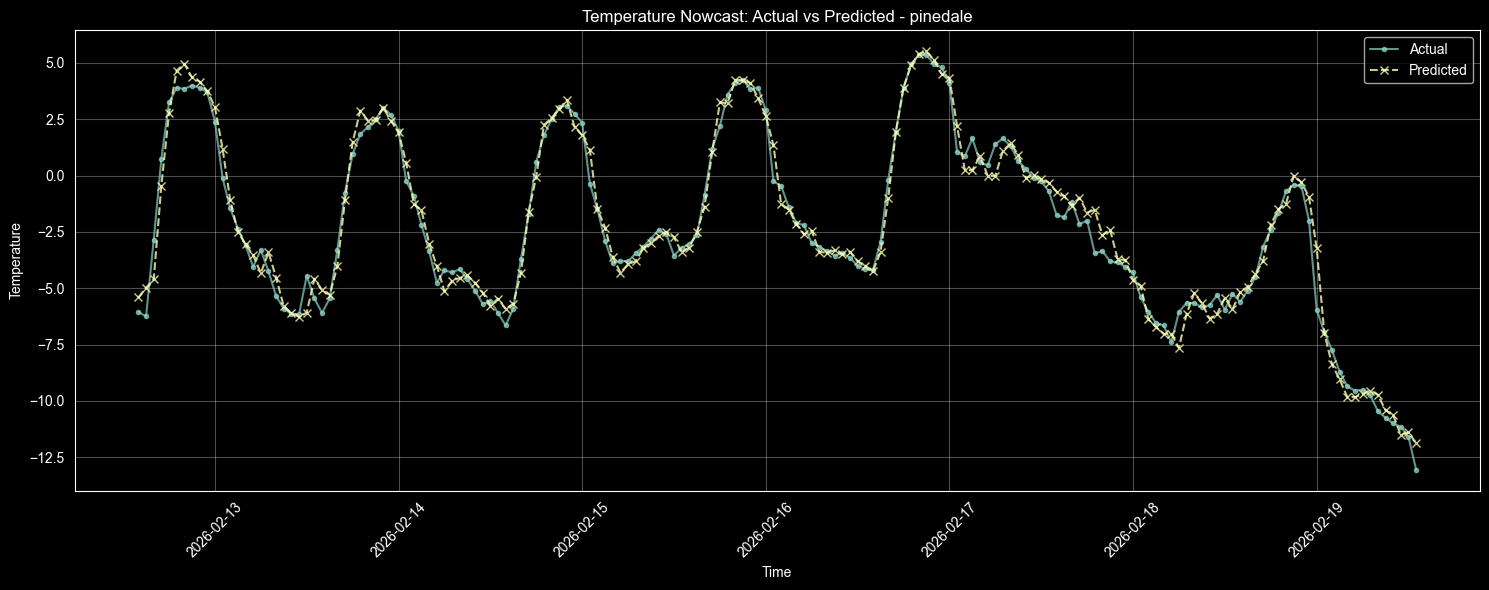

In [6]:
# Extract the time and location information for the test set
# Since we used shuffle=False in train_test_split, X_test corresponds to the last 20% of df_engineered
test_indices = X_test.index
df_test_info = df_engineered.loc[test_indices, ['time', 'location']]

# Create a DataFrame for visualization
viz_df = pd.DataFrame({
    'time': df_test_info['time'],
    'location': df_test_info['location'],
    'Actual Temperature': y_test['temperature'].values,
    'Predicted Temperature': y_pred[:, 0] # Temperature is the first target
})

# Plot for each location (or a specific one)
locations = viz_df['location'].unique()

for loc in locations:
    loc_data = viz_df[viz_df['location'] == loc].tail(168) # Show last 7 days for clarity

    plt.figure(figsize=(15, 6))
    plt.plot(loc_data['time'], loc_data['Actual Temperature'], label='Actual', marker='.', alpha=0.7)
    plt.plot(loc_data['time'], loc_data['Predicted Temperature'], label='Predicted', marker='x', linestyle='--', alpha=0.8)

    plt.title(f"Temperature Nowcast: Actual vs Predicted - {loc}")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
